In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv("/content/weather.csv")

print(df.head())

   Data.Precipitation   Date.Full  Date.Month  Date.Week of  Date.Year  \
0                0.00  2016-01-03           1             3       2016   
1                0.00  2016-01-03           1             3       2016   
2                0.16  2016-01-03           1             3       2016   
3                0.00  2016-01-03           1             3       2016   
4                0.01  2016-01-03           1             3       2016   

  Station.City Station.Code Station.Location Station.State  \
0   Birmingham          BHM   Birmingham, AL       Alabama   
1   Huntsville          HSV   Huntsville, AL       Alabama   
2       Mobile          MOB       Mobile, AL       Alabama   
3   Montgomery          MGM   Montgomery, AL       Alabama   
4    Anchorage          ANC    Anchorage, AK        Alaska   

   Data.Temperature.Avg Temp  Data.Temperature.Max Temp  \
0                         39                         46   
1                         39                         47   
2    

In [4]:
print(df.tail())

       Data.Precipitation   Date.Full  Date.Month  Date.Week of  Date.Year  \
16738                0.08  2017-01-01           1             1       2017   
16739                0.00  2017-01-01           1             1       2017   
16740                0.00  2017-01-01           1             1       2017   
16741                0.06  2017-01-01           1             1       2017   
16742                0.10  2017-01-01           1             1       2017   

      Station.City Station.Code Station.Location Station.State  \
16738       Casper          CPR       Casper, WY       Wyoming   
16739     Cheyenne          CYS     Cheyenne, WY       Wyoming   
16740       Lander          LND       Lander, WY       Wyoming   
16741      Rawlins          RWL      Rawlins, WY       Wyoming   
16742     Sheridan          SHR     Sheridan, WY       Wyoming   

       Data.Temperature.Avg Temp  Data.Temperature.Max Temp  \
16738                         23                         32   
16739   

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16743 entries, 0 to 16742
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Data.Precipitation         16743 non-null  float64
 1   Date.Full                  16743 non-null  object 
 2   Date.Month                 16743 non-null  int64  
 3   Date.Week of               16743 non-null  int64  
 4   Date.Year                  16743 non-null  int64  
 5   Station.City               16743 non-null  object 
 6   Station.Code               16743 non-null  object 
 7   Station.Location           16743 non-null  object 
 8   Station.State              16743 non-null  object 
 9   Data.Temperature.Avg Temp  16743 non-null  int64  
 10  Data.Temperature.Max Temp  16743 non-null  int64  
 11  Data.Temperature.Min Temp  16743 non-null  int64  
 12  Data.Wind.Direction        16743 non-null  int64  
 13  Data.Wind.Speed            16743 non-null  flo

In [6]:
print(df.isnull().sum())

Data.Precipitation           0
Date.Full                    0
Date.Month                   0
Date.Week of                 0
Date.Year                    0
Station.City                 0
Station.Code                 0
Station.Location             0
Station.State                0
Data.Temperature.Avg Temp    0
Data.Temperature.Max Temp    0
Data.Temperature.Min Temp    0
Data.Wind.Direction          0
Data.Wind.Speed              0
dtype: int64


In [7]:
df['Rainfall'] = (df['Data.Precipitation'] > 0).astype(int)

print(df[['Data.Precipitation', 'Rainfall']].head(10))

   Data.Precipitation  Rainfall
0                0.00         0
1                0.00         0
2                0.16         1
3                0.00         0
4                0.01         1
5                0.09         1
6                0.05         1
7                0.15         1
8                0.60         1
9                2.15         1


In [8]:
df['high_temp'] = (
    df['Data.Temperature.Avg Temp'] >=
    df['Data.Temperature.Avg Temp'].median()
).astype(int)

df['high_max_temp'] = (
    df['Data.Temperature.Max Temp'] >=
    df['Data.Temperature.Max Temp'].median()
).astype(int)

df['low_min_temp'] = (
    df['Data.Temperature.Min Temp'] <=
    df['Data.Temperature.Min Temp'].median()
).astype(int)

df['high_wind'] = (
    df['Data.Wind.Speed'] >=
    df['Data.Wind.Speed'].median()
).astype(int)

df['high_wind_direction'] = (
    df['Data.Wind.Direction'] >=
    df['Data.Wind.Direction'].median()
).astype(int)

df['summer_month'] = (
    df['Date.Month'].isin([4, 5, 6, 7, 8, 9])
).astype(int)

In [9]:
X = df[
    [
        'high_temp',
        'high_max_temp',
        'low_min_temp',
        'high_wind',
        'high_wind_direction',
        'summer_month'
    ]
]

y = df['Rainfall']

print(X.head())
print(y.head())

   high_temp  high_max_temp  low_min_temp  high_wind  high_wind_direction  \
0          0              0             1          0                    1   
1          0              0             1          0                    1   
2          0              0             1          1                    1   
3          0              0             1          1                    1   
4          0              0             1          1                    1   

   summer_month  
0             0  
1             0  
2             0  
3             0  
4             0  
0    0
1    0
2    1
3    0
4    1
Name: Rainfall, dtype: int64


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (13394, 6)
Testing data: (3349, 6)


In [11]:
model = BernoulliNB()

model.fit(X_train, y_train)

BernoulliNB()

In [12]:
y_pred = model.predict(X_test)

print(y_pred)

[1 1 1 ... 1 1 1]


In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Accuracy: 0.7467900865930128
Accuracy Percentage: 74.67900865930129 %


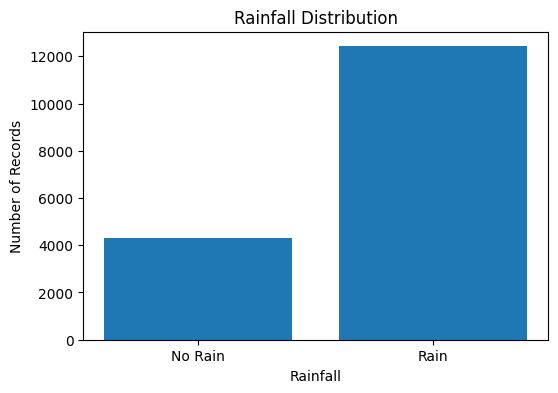

In [14]:
rain_count = df['Rainfall'].value_counts()

plt.figure(figsize=(6, 4))

plt.bar(
    ['No Rain', 'Rain'],
    [
        rain_count.get(0, 0),
        rain_count.get(1, 0)
    ]
)

plt.xlabel("Rainfall")
plt.ylabel("Number of Records")
plt.title("Rainfall Distribution")

plt.show()


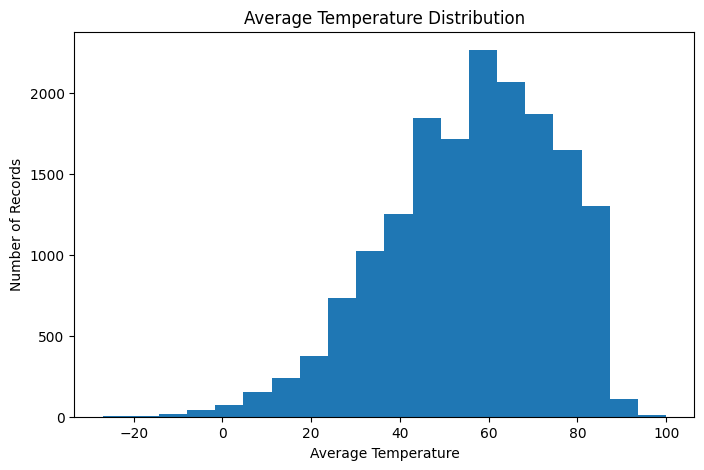

In [15]:
plt.figure(figsize=(8, 5))

plt.hist(
    df['Data.Temperature.Avg Temp'],
    bins=20
)

plt.xlabel("Average Temperature")
plt.ylabel("Number of Records")
plt.title("Average Temperature Distribution")

plt.show()

In [16]:
print("Enter Weather Details")

avg_temp = float(input("Enter Average Temperature: "))
max_temp = float(input("Enter Maximum Temperature: "))
min_temp = float(input("Enter Minimum Temperature: "))
wind_speed = float(input("Enter Wind Speed: "))
wind_direction = float(input("Enter Wind Direction: "))
month = int(input("Enter Month (1-12): "))

high_temp = int(
    avg_temp >= df['Data.Temperature.Avg Temp'].median()
)

high_max_temp = int(
    max_temp >= df['Data.Temperature.Max Temp'].median()
)

low_min_temp = int(
    min_temp <= df['Data.Temperature.Min Temp'].median()
)

high_wind = int(
    wind_speed >= df['Data.Wind.Speed'].median()
)

high_wind_direction = int(
    wind_direction >= df['Data.Wind.Direction'].median()
)

summer_month = int(
    month in [4, 5, 6, 7, 8, 9]
)

user_data = [[
    high_temp,
    high_max_temp,
    low_min_temp,
    high_wind,
    high_wind_direction,
    summer_month
]]

prediction = model.predict(user_data)

if prediction[0] == 1:
    print("Prediction: Rain")
else:
    print("Prediction: No Rain")

Enter Weather Details
Enter Average Temperature: 65
Enter Maximum Temperature: 72
Enter Minimum Temperature: 85
Enter Wind Speed: 10
Enter Wind Direction: 20
Enter Month (1-12): 6
Prediction: Rain


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but BernoulliNB was fitted with feature names
  warnings.warn(
